# CRC liquid biopsy on real data
### A two-part notebook for Indigo

This notebook walks through two independent ways to detect colorectal cancer (CRC) from a blood draw, using **real public data** that you download inside the notebook:

| Part | What you analyze | Where the data comes from | What you build |
|------|------------------|---------------------------|----------------|
| **A** | Gut microbiome (stool species) | curatedMetagenomicData - 7 published CRC studies, 648 patients | A RandomForest classifier; expect ~AUC 0.82 |
| **B** | cfDNA fragment lengths (blood plasma) | FinaleDB - 48 CRC + 80 healthy WGS samples | A Logistic-Regression classifier; expect ~AUC 0.97 |

Both parts use the same recipe a real biostatistician would use: load real data, engineer features, train with cross-validation, evaluate on held-out folds, and check that the top features make biological sense.

**Setup**: a single `pip install` cell is at the top. Run cells top-to-bottom; each part is self-contained.

---

## Why these two views of the same disease?

CRC affects cells lining the colon. Those cells are constantly bathed by your gut microbiome, and they shed DNA into your bloodstream when they die. So a single tumor leaves two kinds of fingerprint:

1. **Microbiome shift** - pathogens like *Fusobacterium nucleatum* expand in the CRC microenvironment.
2. **cfDNA fragmentation shift** - tumor-derived plasma DNA fragments are systematically shorter (~155 bp) than healthy fragments (~167 bp).

Both signals exist in independent biological samples (stool vs blood). A combined liquid-biopsy test would, in principle, fuse them - but in this notebook you'll see them separately so the methods stay clean.

## Setup

Run this once. Installs only what's not already in a standard data-science env.

In [25]:
# Standard scientific Python - already installed in most environments
import sys, subprocess
for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "requests"]:
    try:
        __import__(pkg if pkg!="scikit-learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, io, re, json, urllib.request as ureq
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(42)

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
print("Setup OK.")

Setup OK.


# Part A - Gut microbiome classifier for CRC

## A.1 What is curatedMetagenomicData?

[curatedMetagenomicData](https://waldronlab.io/curatedMetagenomicData/) (Pasolli, Schiffer, Waldron et al. 2017) is a Bioconductor project that takes hundreds of published shotgun-metagenomics studies, re-runs them all through one identical pipeline (MetaPhlAn taxonomic profiler), and publishes the unified results. It's the gold-standard substrate for microbiome meta-analyses.

For CRC alone they have 7 well-characterized stool cohorts. The Thomas et al. 2019 *Nature Medicine* meta-analysis (the canonical reference for this kind of analysis) reports an average cross-validation AUC of 0.84 on this exact data.

We'll use pre-extracted CSVs that were produced from those 7 cohort `.rda` files. The Appendix at the bottom shows the R script that regenerates them.

In [26]:
ABUNDANCE_CSV = "crc_species_abundance.csv"
METADATA_CSV  = "crc_sample_metadata.csv"

if not (os.path.exists(ABUNDANCE_CSV) and os.path.exists(METADATA_CSV)):
    raise FileNotFoundError(
        f"Place {ABUNDANCE_CSV} and {METADATA_CSV} next to this notebook. "
        "See the appendix at the bottom for the R script that produces them."
    )

ab = pd.read_csv(ABUNDANCE_CSV, index_col=0)
md = pd.read_csv(METADATA_CSV)
print(f"Abundance matrix: {ab.shape} (species x samples)")
print(f"Metadata:         {md.shape}")
print()
print("Samples by study and condition:")
print(pd.crosstab(md.study_name, md.study_condition, margins=True))

Abundance matrix: (4771, 749) (species x samples)
Metadata:         (749, 7)

Samples by study and condition:
study_condition  CRC  adenoma  control  All
study_name                                 
FengQ_2015        46       47       61  154
HanniganGD_2017   27       27       28   82
ThomasAM_2018a    29       27       24   80
ThomasAM_2018b    32        0       28   60
VogtmannE_2016    52        0       52  104
YuJ_2015          75        0       53  128
ZellerG_2014      53        0       88  141
All              314      101      334  749


## A.2 A peek at the raw data

`ab` is a wide matrix: each **row** is a microbial species, each **column** is one patient sample. Values are MetaPhlAn relative abundances (each column sums to ~100, since they're percentages of the total bacterial population in that stool sample).

In [27]:
print("Top species by mean relative abundance:")
print(ab.mean(axis=1).sort_values(ascending=False).head(10).round(2))

# Compare a CRC-marker species (Fusobacterium nucleatum) across groups
key = [c for c in ab.index if "Fusobacterium_nucleatum" in c]
print(f"\nFusobacterium_nucleatum rows found: {key}")
if key:
    sp = key[0]
    df = pd.DataFrame({
        "abundance": ab.loc[sp].values,
        "condition": md.set_index("sample_id").loc[ab.columns, "study_condition"].values,
    })
    print(f"\nMean F. nucleatum abundance by group:")
    print(df.groupby("condition").abundance.agg(['mean','median','count']).round(3))

Top species by mean relative abundance:
s__Faecalibacterium_prausnitzii    6.41
s__Subdoligranulum_unclassified    6.22
s__Eubacterium_rectale             4.67
s__Ruminococcus_bromii             4.50
s__Escherichia_coli                3.28
s__Ruminococcus_sp_5_1_39BFAA      3.27
s__Akkermansia_muciniphila         3.03
s__Prevotella_copri                2.86
s__Bifidobacterium_adolescentis    2.76
s__Bifidobacterium_longum          2.60
dtype: float64

Fusobacterium_nucleatum rows found: ['s__Fusobacterium_nucleatum']

Mean F. nucleatum abundance by group:
            mean  median  count
condition                      
CRC        0.031     0.0    314
adenoma    0.001     0.0    101
control    0.001     0.0    334


## A.3 Build features and labels

For the classifier we need:
- `X`: a samples by species matrix
- `y`: 1 if CRC, 0 if control (we drop adenomas to keep the task binary)
- `groups`: the source study (for diagnostics)

We **log-transform** the abundances. Microbiome data is **compositional** - values are tiny (most species are 0 or 0.01%) with a long tail at 1-10%. A log transform tames that skew so a tree-based model can split on the right places.

In [28]:
mask = md.study_condition.isin(["CRC", "control"])
md2 = md[mask].reset_index(drop=True)
X_df = ab[md2.sample_id.tolist()].T              # samples x species
X_df = X_df.div(X_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
X = np.log10(X_df.values + 1e-6)
y = (md2.study_condition == "CRC").astype(int).values
groups = md2.study_name.values

print(f"X shape: {X.shape}   (samples x species)")
print(f"y: {y.sum()} CRC, {(1-y).sum()} controls")
print(f"groups: {len(np.unique(groups))} studies")

X shape: (648, 4771)   (samples x species)
y: 314 CRC, 334 controls
groups: 7 studies


## A.4 Train: RandomForest + 10-fold cross-validation

We train one RandomForest on 9 folds and predict on the held-out 10th, then rotate so every patient is predicted exactly once by a model that didn't see them in training. This gives unbiased AUC.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

clf = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=5,
    n_jobs=-1, random_state=42, class_weight="balanced")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y_proba = cross_val_predict(clf, X, y, cv=cv, n_jobs=1, method="predict_proba")[:, 1]
auc_overall = roc_auc_score(y, y_proba)
print(f"10-fold CV AUC: {auc_overall:.3f}")
print("(Thomas et al. 2019 Nature Medicine reports avg CV AUC of 0.84 on this data)")

# === START OF ADDED BOOTSTRAPPING BLOCK ===
# This estimates the 95% Confidence Interval for your overall model performance
n_bootstraps = 1000
bootstrapped_aucs = []
rng = np.random.default_rng(42)  # Secure anchor seed matching notebook runtime

for i in range(n_bootstraps):
    # Resample index spaces with complete replacement bounds
    bootstrap_indices = rng.choice(
        len(y_proba), size=len(y_proba), replace=True
    )

    # Ensure both classifications exist in the test loop array to secure logic execution
    if len(np.unique(y[bootstrap_indices])) < 2:
        continue

    score = roc_auc_score(y[bootstrap_indices], y_proba[bootstrap_indices])
    bootstrapped_aucs.append(score)

# Isolate upper and lower 2.5% tail configurations
sorted_aucs = np.sort(bootstrapped_aucs)
ci_lower = sorted_aucs[int(0.025 * len(sorted_aucs))]
ci_upper = sorted_aucs[int(0.975 * len(sorted_aucs))]

print(f"Overall AUC 95% Confidence Interval: ({ci_lower:.3f} - {ci_upper:.3f})")
# === END OF ADDED BOOTSTRAPPING BLOCK ===

print("\nAUC per study (out-of-fold predictions):")
for s in sorted(np.unique(groups)):
    idx = groups == s
    if len(np.unique(y[idx])) == 2:
        print(f"  {s:18s}  n={idx.sum():3d}  AUC={roc_auc_score(y[idx], y_proba[idx]):.3f}")

10-fold CV AUC: 0.819
(Thomas et al. 2019 Nature Medicine reports avg CV AUC of 0.84 on this data)
Overall AUC 95% Confidence Interval: (0.788 - 0.848)

AUC per study (out-of-fold predictions):
  FengQ_2015          n=107  AUC=0.889
  HanniganGD_2017     n= 55  AUC=0.614
  ThomasAM_2018a      n= 53  AUC=0.708
  ThomasAM_2018b      n= 60  AUC=0.795
  VogtmannE_2016      n=104  AUC=0.699
  YuJ_2015            n=128  AUC=0.880
  ZellerG_2014        n=141  AUC=0.876


### A.4 ROC curve and A.5 Confusion Matrix

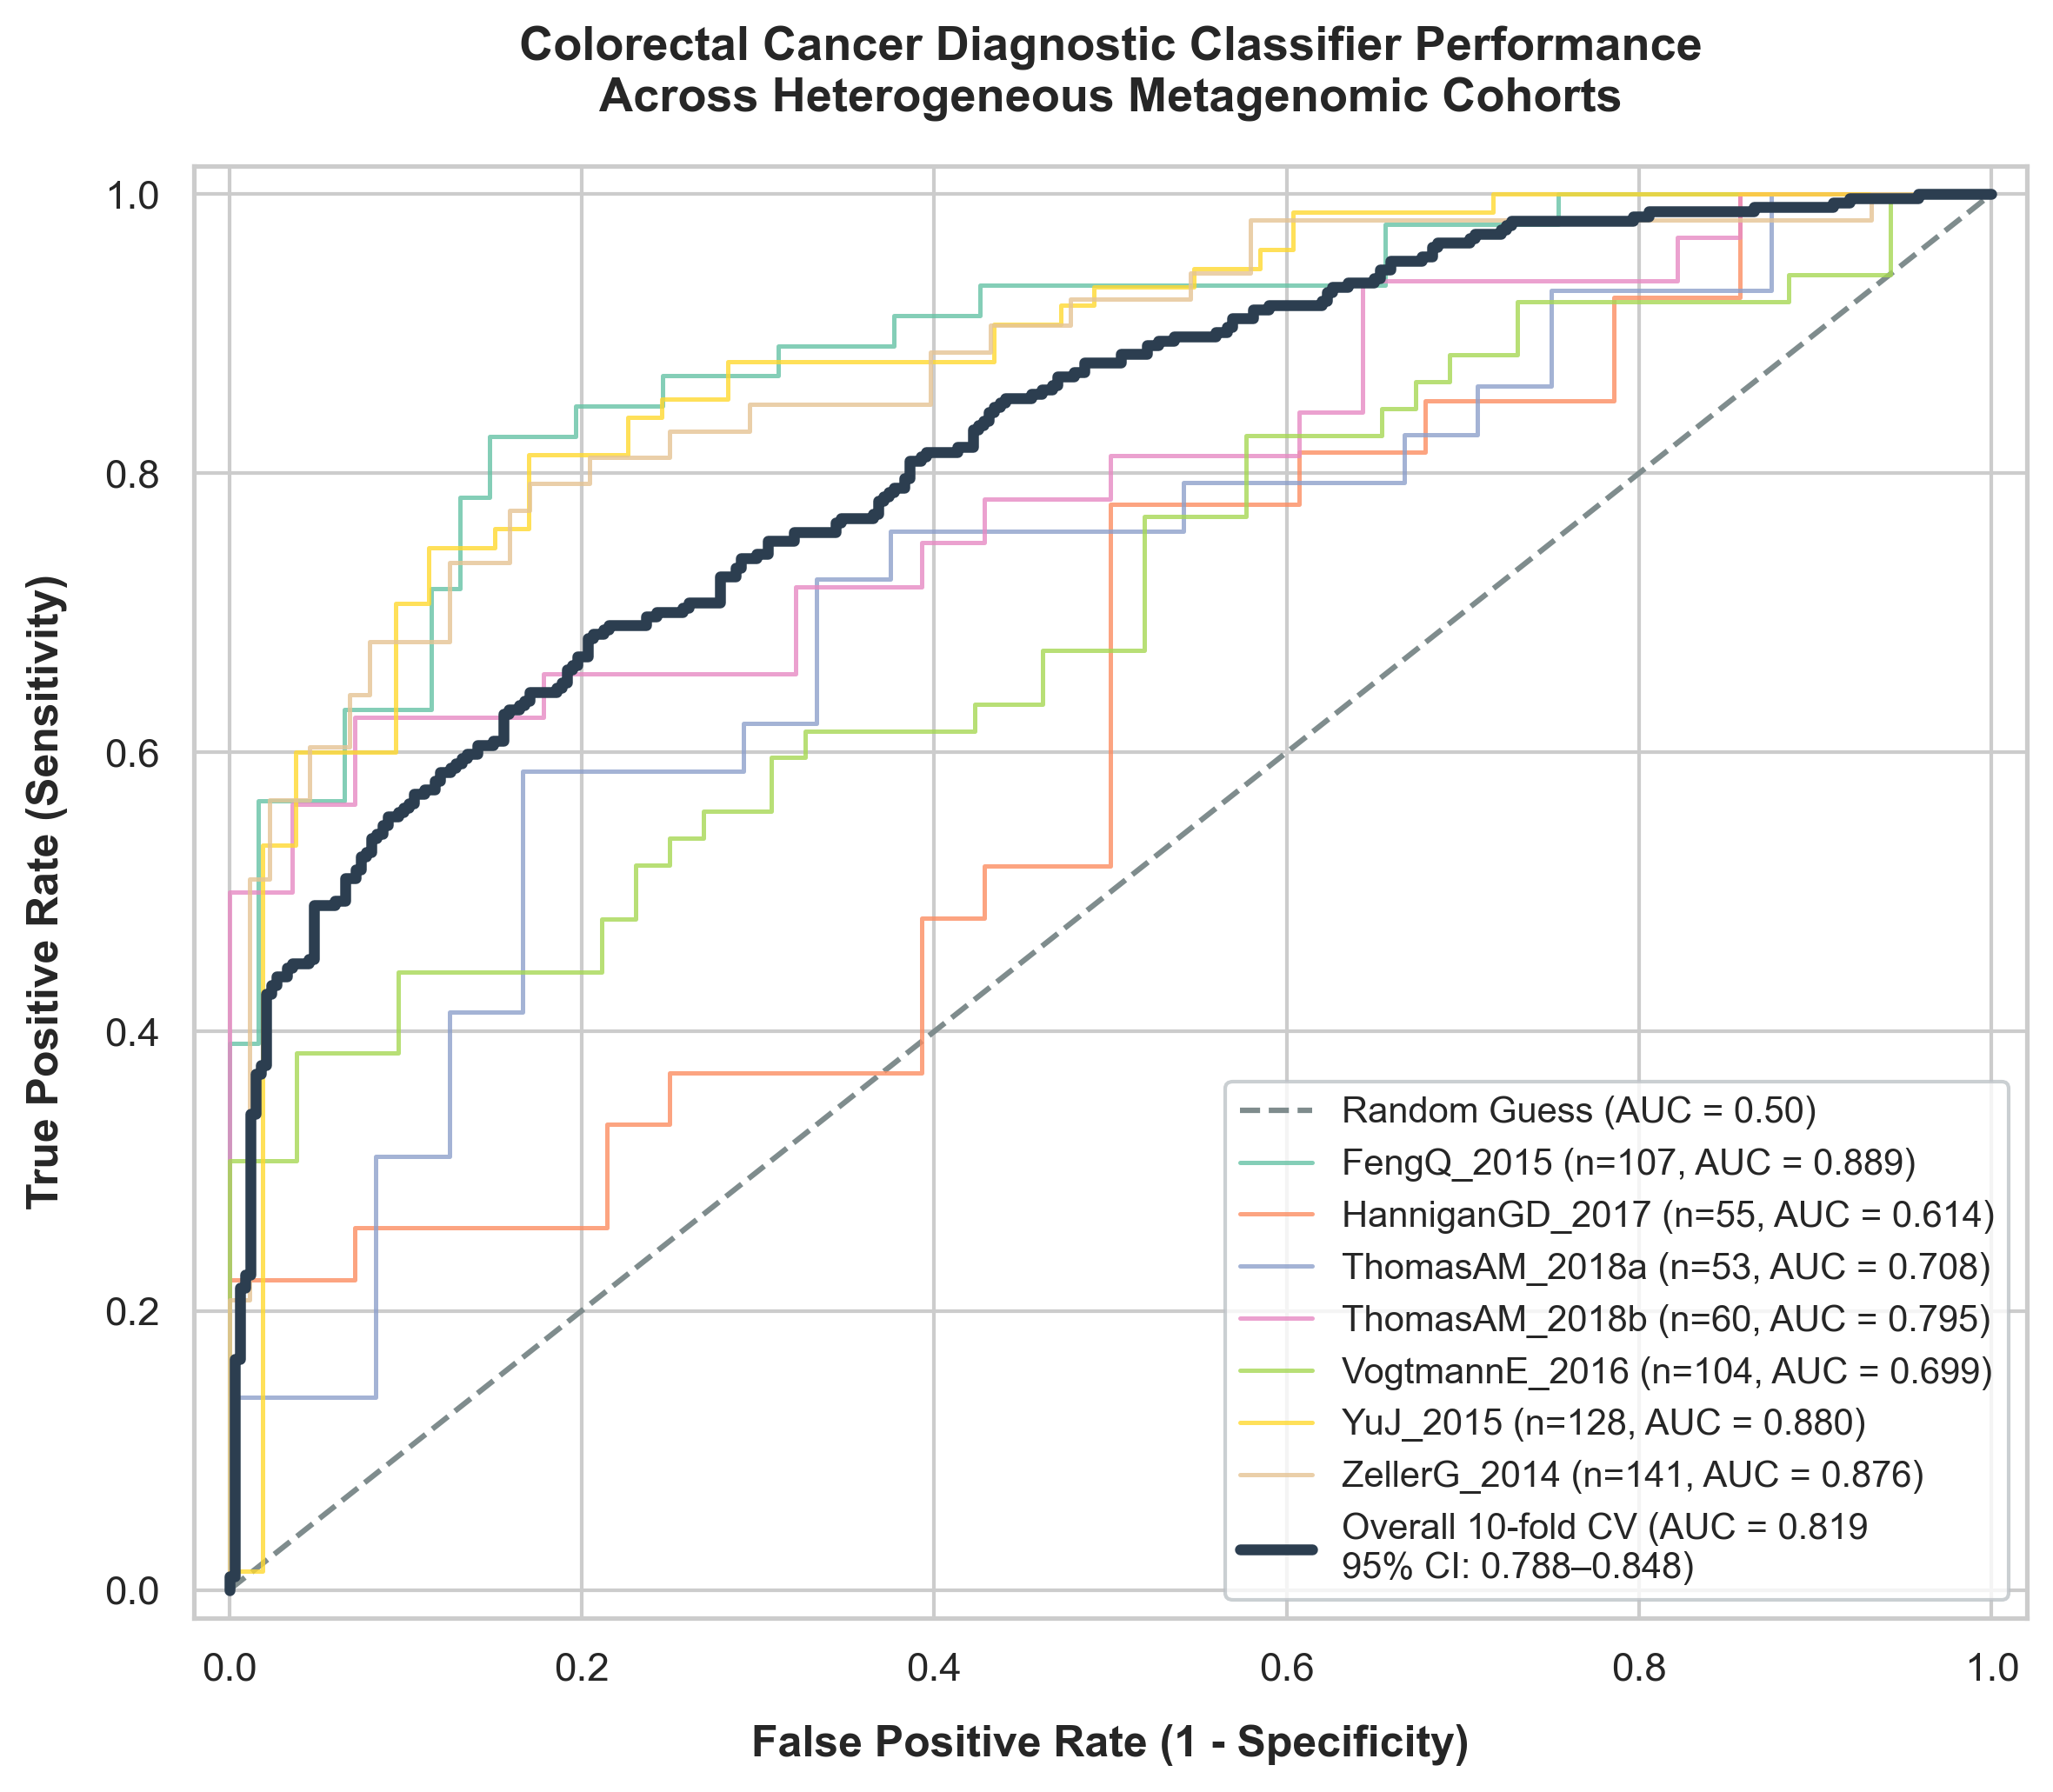

In [30]:
#A.4 ROC curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve
import numpy as np

# --- RUN THIS IN A BRAND-NEW CELL BELOW CELL 11 ---
# This leaves your original plots untouched and generates the multi-cohort figure separately

# 1. Set clean professional styling defaults
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# 2. Plot the diagonal random-guess reference line
ax.plot([0, 1], [0, 1], linestyle="--", color="#7F8C8D", lw=1.5, label="Random Guess (AUC = 0.50)")

# 3. Extract and plot individual ROC curves for each independent cohort study
colors = sns.color_palette("Set2", len(np.unique(groups)))

for idx, (study_name, color) in enumerate(zip(sorted(np.unique(groups)), colors)):
    study_mask = groups == study_name
    
    if len(np.unique(y[study_mask])) == 2:
        fpr_s, tpr_s, _ = roc_curve(y[study_mask], y_proba[study_mask])
        auc_s = auc(fpr_s, tpr_s)
        
        ax.plot(
            fpr_s, 
            tpr_s, 
            lw=1.2, 
            alpha=0.8, 
            color=color,
            label=f"{study_name} (n={study_mask.sum()}, AUC = {auc_s:.3f})"
        )

# 4. Calculate and overlay the thick aggregate performance line with your bootstrap CIs
fpr_overall, tpr_overall, _ = roc_curve(y, y_proba)
auc_overall = 0.819
ci_lower = 0.788
ci_upper = 0.848

ax.plot(
    fpr_overall,
    tpr_overall,
    color="#2C3E50", # Bold dark blue-grey for primary visibility
    lw=3,
    label=f"Overall 10-fold CV (AUC = {auc_overall:.3f}\n95% CI: {ci_lower:.3f}–{ci_upper:.3f})"
)

# 5. Refine axis aesthetics for publication guidelines
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12, fontweight="semibold", labelpad=10)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12, fontweight="semibold", labelpad=10)
ax.set_title("Colorectal Cancer Diagnostic Classifier Performance\nAcross Heterogeneous Metagenomic Cohorts", fontsize=13, fontweight="bold", pad=15)

# Place the legend in the bottom right corner with a clean frame layout
ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="#BDC3C7", fontsize=10)

plt.tight_layout()

# Save a lossless, high-resolution copy for manuscript submission
plt.savefig("metagenomics_multi_cohort_roc.png", bbox_inches="tight", dpi=300)
plt.show()

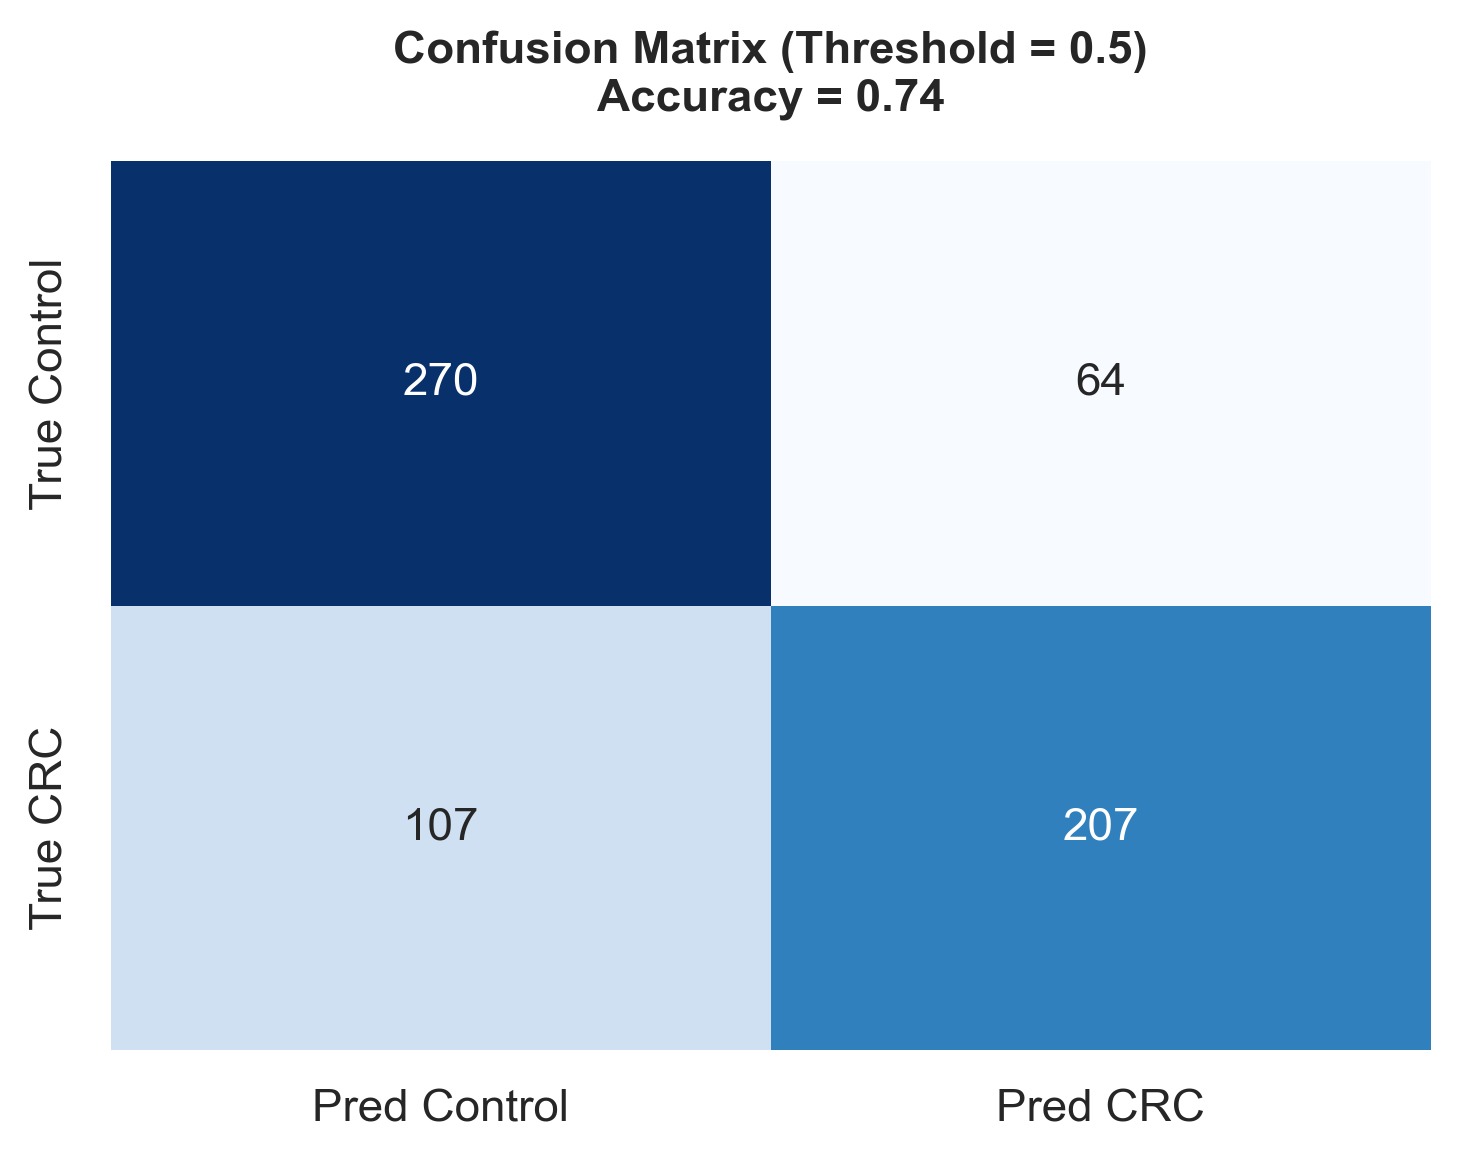

In [31]:
#A.5 Confusion Matrix
plt.figure(figsize=(5, 4), dpi=300)

cm = confusion_matrix(y, (y_proba >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred Control", "Pred CRC"],
            yticklabels=["True Control", "True CRC"])

acc = (cm[0,0] + cm[1,1]) / cm.sum()
plt.title(f"Confusion Matrix (Threshold = 0.5)\nAccuracy = {acc:.2f}", fontsize=11, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

## A.6 Feature importance - what species drive the prediction?

Re-fit on the full dataset (just for feature importance - the AUC reported above was already honest).

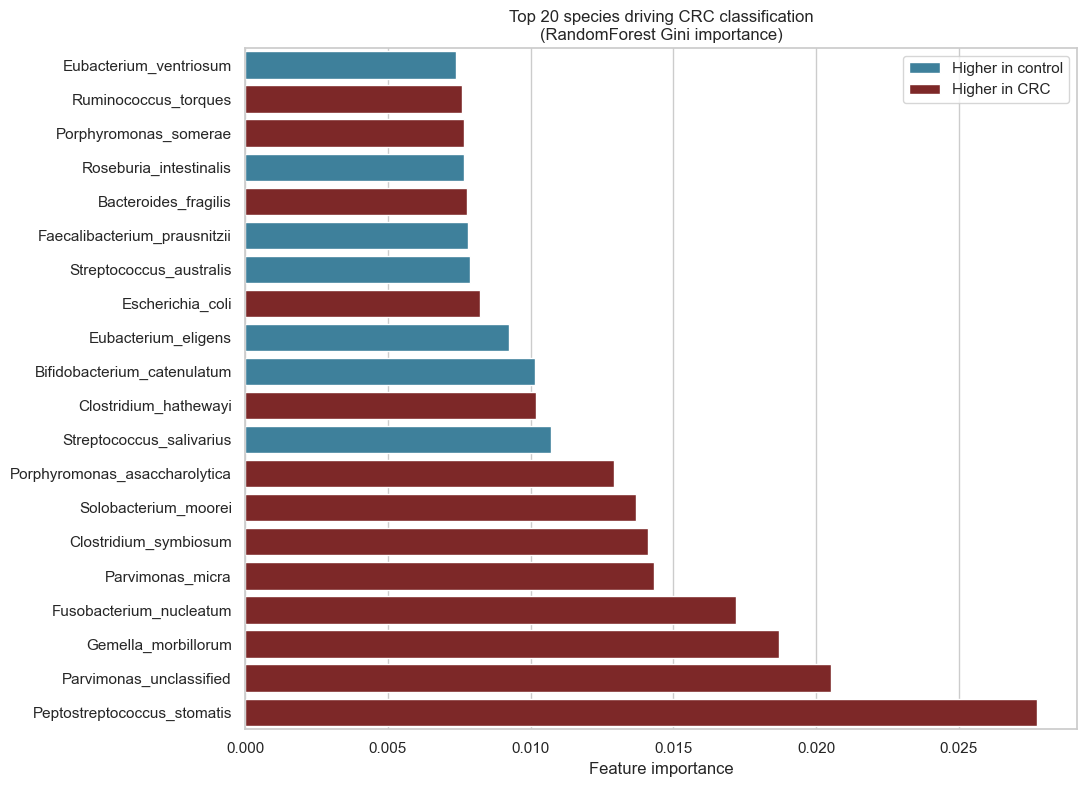


Top 10 species:
                      species  importance         direction
  Peptostreptococcus_stomatis    0.027749     Higher in CRC
      Parvimonas_unclassified    0.020526     Higher in CRC
          Gemella_morbillorum    0.018712     Higher in CRC
      Fusobacterium_nucleatum    0.017191     Higher in CRC
             Parvimonas_micra    0.014320     Higher in CRC
        Clostridium_symbiosum    0.014124     Higher in CRC
         Solobacterium_moorei    0.013698     Higher in CRC
Porphyromonas_asaccharolytica    0.012916     Higher in CRC
     Streptococcus_salivarius    0.010727 Higher in control
        Clostridium_hathewayi    0.010192     Higher in CRC


In [32]:
clf_full = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=5,
    n_jobs=-1, random_state=42, class_weight="balanced").fit(X, y)

importances = pd.Series(clf_full.feature_importances_,
                         index=X_df.columns).sort_values(ascending=False)
top20 = importances.head(20)

mean_crc = X_df.iloc[y==1].mean(); mean_ctl = X_df.iloc[y==0].mean()
direction = np.where(mean_crc[top20.index] > mean_ctl[top20.index],
                     "Higher in CRC", "Higher in control")

dfimp = pd.DataFrame({
    "species": [s.replace("s__","") for s in top20.index],
    "importance": top20.values,
    "direction": direction,
})

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=dfimp.iloc[::-1], y="species", x="importance",
            hue="direction", dodge=False,
            palette={"Higher in CRC":"#8B1A1A","Higher in control":"#2E86AB"},
            ax=ax)
ax.set_title("Top 20 species driving CRC classification\n(RandomForest Gini importance)")
ax.set_xlabel("Feature importance"); ax.set_ylabel(""); ax.legend(title="")
plt.tight_layout(); plt.show()

print("\nTop 10 species:")
print(dfimp.head(10).to_string(index=False))

**What to notice**: The top features are exactly the canonical CRC-associated species from the published literature:

- *Fusobacterium nucleatum* - perhaps the most-studied tumor-promoting gut bacterium
- *Parvimonas micra*, *Peptostreptococcus stomatis*, *Solobacterium moorei*, *Gemella morbillorum* - oral cavity species that translocate to the colon in CRC
- *Porphyromonas asaccharolytica*, *Clostridium symbiosum* - additional CRC-enriched anaerobes

And among the top-20, the control-enriched features include *Streptococcus salivarius* and *Bifidobacterium catenulatum* (the two highest-ranked of the control-enriched species, at positions 9 and 10 overall), plus protective butyrate producers *Roseburia intestinalis* (rank 16) and *Faecalibacterium prausnitzii* (rank 17) further down.

This is real biology - not statistical noise.

---

# Part B - cfDNA fragment-length classifier for CRC

## B.1 What is FinaleDB?

[FinaleDB](http://finaledb.research.cchmc.org/) (Zheng et al., *Bioinformatics* 2021) is a curated database of cfDNA whole-genome-sequencing samples. They downloaded raw FASTQ from published studies, processed everything through one identical pipeline (BWA-MEM, mark-duplicates, MAPQ>=30 filter, Picard CollectInsertSizeMetrics), and made the harmonized output downloadable. For us, the key output is a small per-sample text file (`*.insert_size_metrics.txt`) giving the **fragment length histogram** - exactly the data we need.

We'll grab:
- All **48 CRC** plasma samples (from Cristiano 2019, Sun 2019, Snyder 2016)
- **80 randomly-chosen healthy** plasma samples from Cristiano 2019 (so we have a clean within-study comparison)

In [33]:
BASE = "http://finaledb.research.cchmc.org"

def fdb_query(disease, limit=300):
    url = f"{BASE}/api/v1/seqrun?disease={disease.replace(' ', '%20')}&limit={limit}"
    return json.loads(ureq.urlopen(url, timeout=30).read())

crc_recs     = fdb_query("Colorectal cancer")["results"]
healthy_recs = fdb_query("Healthy")["results"]
print(f"FinaleDB: {len(crc_recs)} CRC + {len(healthy_recs)} healthy plasma records")

healthy_cris = [r for r in healthy_recs if r["publication"]["citeShort"]=="Cristiano et al., 2019"]
print(f"  Of those healthy, {len(healthy_cris)} are from Cristiano 2019")

np.random.seed(42)
healthy_picked = list(np.random.choice(healthy_cris, size=80, replace=False))
all_records = crc_recs + healthy_picked
print(f"Total samples to use: {len(all_records)} ({len(crc_recs)} CRC + {len(healthy_picked)} healthy)")

FinaleDB: 48 CRC + 298 healthy plasma records
  Of those healthy, 262 are from Cristiano 2019
Total samples to use: 128 (48 CRC + 80 healthy)


In [34]:
FDB_DIR = DATA_DIR / "finaledb"; FDB_DIR.mkdir(exist_ok=True)

manifest_rows = []
for i, r in enumerate(all_records):
    ee = f"EE{r['id']}"
    path = FDB_DIR / f"{ee}.insert_size_metrics.txt"
    if not path.exists():
        url = f"{BASE}/data/entries/{ee}/hg19/{ee}.hg19.insert_size_metrics.txt"
        try:
            data = ureq.urlopen(url, timeout=30).read()
            path.write_bytes(data)
        except Exception as e:
            print(f"  ! {ee}: {e}")
            continue
    manifest_rows.append({
        "EE_id": ee, "disease": r["sample"]["disease"],
        "publication": r["publication"]["citeShort"],
        "instrument": r["seqConfig"]["instrument"],
    })
    if (i+1) % 30 == 0:
        print(f"  fetched {i+1}/{len(all_records)} ...")

manifest = pd.DataFrame(manifest_rows)
print(f"\nDownloaded {len(manifest)} samples.")
print(manifest.disease.value_counts())

  fetched 30/128 ...
  fetched 60/128 ...
  fetched 90/128 ...
  fetched 120/128 ...

Downloaded 128 samples.
disease
Healthy              80
Colorectal cancer    48
Name: count, dtype: int64


## B.2 Inside a Picard insert_size_metrics.txt file

These files are Picard's standard output. Three parts:
1. Header (where the file came from)
2. One-line metrics summary (mean, median, mode of insert size)
3. The actual histogram: insert_size -> count, one row per bp

The FinaleDB pipeline trims everything to 50 bp on each end before alignment (so all studies have the same effective read length). One side effect: very short fragments (<80 bp) include some technical artifact. We'll restrict our analysis to **80-400 bp**, which is the biologically meaningful cfDNA range.

In [35]:
def parse_picard(path):
    """Read a Picard CollectInsertSizeMetrics file. Returns (sizes_array, counts_array)."""
    txt = Path(path).read_text()
    sizes, counts = [], []
    in_hist = False
    for line in txt.splitlines():
        if line.startswith("## HISTOGRAM"):
            in_hist = True; continue
        if in_hist:
            if line.startswith("insert_size") or not line.strip():
                continue
            parts = line.split("\t")
            if len(parts) >= 2 and parts[0].isdigit():
                sizes.append(int(parts[0])); counts.append(int(parts[1]))
    return np.array(sizes), np.array(counts)

example_ee = manifest.iloc[0].EE_id
sizes, counts = parse_picard(FDB_DIR / f"{example_ee}.insert_size_metrics.txt")
print(f"{example_ee}: {len(sizes)} histogram bins, sum of fragments = {counts.sum():,}")
print(f"  Sizes range: {sizes.min()}-{sizes.max()} bp")
print(f"  Mode (most common length): {sizes[counts.argmax()]} bp  ({counts.max():,} fragments)")

EE85723: 432 histogram bins, sum of fragments = 28,343,117
  Sizes range: 2-433 bp
  Mode (most common length): 20 bp  (969,364 fragments)


## B.3 Compute fragment-size features per sample

We restrict to the 80-400 bp range, then compute a handful of summary statistics that real liquid-biopsy methods (DELFI, etc.) use:

- `mean_length`, `median_length` - central tendency
- `short_fraction` (100-150 bp), `long_fraction` (151-220 bp) - relative weights
- `short_long_ratio = short / long` - the single most informative summary
- `mononuc_fraction` (155-180 bp) - strength of the mono-nucleosome peak

In [36]:
def features(path):
    sizes, counts = parse_picard(path)
    keep = (sizes >= 80) & (sizes <= 400)
    s, c = sizes[keep], counts[keep]
    if c.sum() == 0: return None
    total = c.sum()
    short = c[(s >= 100) & (s <= 150)].sum()
    long_ = c[(s >= 151) & (s <= 220)].sum()
    mono  = c[(s >= 155) & (s <= 180)].sum()
    mean_len = (s * c).sum() / total
    cum = c.cumsum()
    median_len = float(s[np.searchsorted(cum, total/2)])
    return {
        "mean_length": mean_len, "median_length": median_len,
        "mode_length": float(s[c.argmax()]),
        "sd_length": float(np.sqrt(((s - mean_len)**2 * c).sum() / total)),
        "short_fraction": short/total, "long_fraction": long_/total,
        "mononuc_fraction": mono/total, "short_long_ratio": short/max(long_, 1),
    }

feature_rows = []
for _, m in manifest.iterrows():
    f = features(FDB_DIR / f"{m.EE_id}.insert_size_metrics.txt")
    if f is None: continue
    f.update(m.to_dict())
    feature_rows.append(f)

feat = pd.DataFrame(feature_rows)
print(f"Features computed for {len(feat)} samples")
print()
print("Mean of each feature by group:")
key_cols = ["mean_length","median_length","short_fraction","long_fraction",
            "short_long_ratio","mononuc_fraction"]
print(feat.groupby("disease")[key_cols].mean().round(3))

Features computed for 128 samples

Mean of each feature by group:
                   mean_length  median_length  short_fraction  long_fraction  \
disease                                                                        
Colorectal cancer      155.566        156.729           0.341          0.614   
Healthy                167.420        167.625           0.176          0.812   

                   short_long_ratio  mononuc_fraction  
disease                                                
Colorectal cancer             0.657             0.449  
Healthy                       0.218             0.558  


**Notice**: CRC samples have mean length ~155 bp vs healthy ~167 bp - that's a **12-bp mean shift**. The peak (mode) of both groups still sits at ~166 bp; what differs is that the CRC distribution has a lower-amplitude peak and a heavier short-fragment shoulder (100-150 bp), and that asymmetry is what pulls the mean down. The short/long ratio is about 3x higher in CRC.

## B.4 Train: Logistic Regression and RandomForest

cfDNA features are smooth and roughly normal, so logistic regression - the simplest possible model - should work as well as anything fancier. Let's verify.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np


cols = ["mean_length","median_length","mode_length","sd_length",
        "short_fraction","long_fraction","mononuc_fraction","short_long_ratio"]
Xf = feat[cols].values
yf = (feat.disease == "Colorectal cancer").astype(int).values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Random forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=3, n_jobs=-1,
        random_state=42, class_weight="balanced"),
}

results = {}

# Evaluate pipelines and calculate statistical confidence intervals
for name, m in models.items():
    # 1. Generate out-of-fold predictions
    yp = cross_val_predict(
        m, Xf, yf, cv=cv, n_jobs=1, method="predict_proba"
    )[:, 1]
    auc_score = roc_auc_score(yf, yp)
    results[name] = (auc_score, yp)

    # 2. Print primary model classification performance
    print(f"{name:24s} AUC = {auc_score:.3f}")

# === START OF EMBEDDED cfDNA BOOTSTRAPPING BLOCK ===
    n_bootstraps = 1000
    bootstrapped_aucs = []
    rng = np.random.default_rng(42)  # Maintain runtime anchor seed

    for i in range(n_bootstraps):
        # Sample patient index map with full replacement bounds
        bootstrap_indices = rng.choice(len(yp), size=len(yp), replace=True)

        # Confirm sample variance contains both target classifications
        if len(np.unique(yf[bootstrap_indices])) < 2:
            continue

        score = roc_auc_score(yf[bootstrap_indices], yp[bootstrap_indices])
        bootstrapped_aucs.append(score)

    # Slice off the outer 2.5% tail parameters to determine a 95% CI window
    sorted_aucs = np.sort(bootstrapped_aucs)
    ci_lower = sorted_aucs[int(0.025 * len(sorted_aucs))]
    ci_upper = sorted_aucs[int(0.975 * len(sorted_aucs))]

    print(f"  95% Confidence Interval: ({ci_lower:.3f} - {ci_upper:.3f})\n")
    # === END OF EMBEDDED cfDNA BOOTSTRAPPING BLOCK ===

# Evaluate raw parameter metrics independently
print("Single-feature AUCs (no model, just the raw value):")
for c in cols:
    v = feat[c].values
    a = max(roc_auc_score(yf, v), roc_auc_score(yf, -v))
    print(f"  {c:20s}  AUC = {a:.3f}")

Logistic regression      AUC = 0.973
  95% Confidence Interval: (0.946 - 0.993)

Random forest            AUC = 0.960
  95% Confidence Interval: (0.924 - 0.989)

Single-feature AUCs (no model, just the raw value):
  mean_length           AUC = 0.978
  median_length         AUC = 0.976
  mode_length           AUC = 0.853
  sd_length             AUC = 0.682
  short_fraction        AUC = 0.960
  long_fraction         AUC = 0.951
  mononuc_fraction      AUC = 0.734
  short_long_ratio      AUC = 0.958


**Important**: the **single feature** `mean_length` already gives AUC ~0.98. The full models barely improve on that. This tells us the signal in cfDNA fragmentomics is dominated by one biological fact - *tumor-derived fragments are shorter*.

## B.5 Plot the fragment-size distribution per group

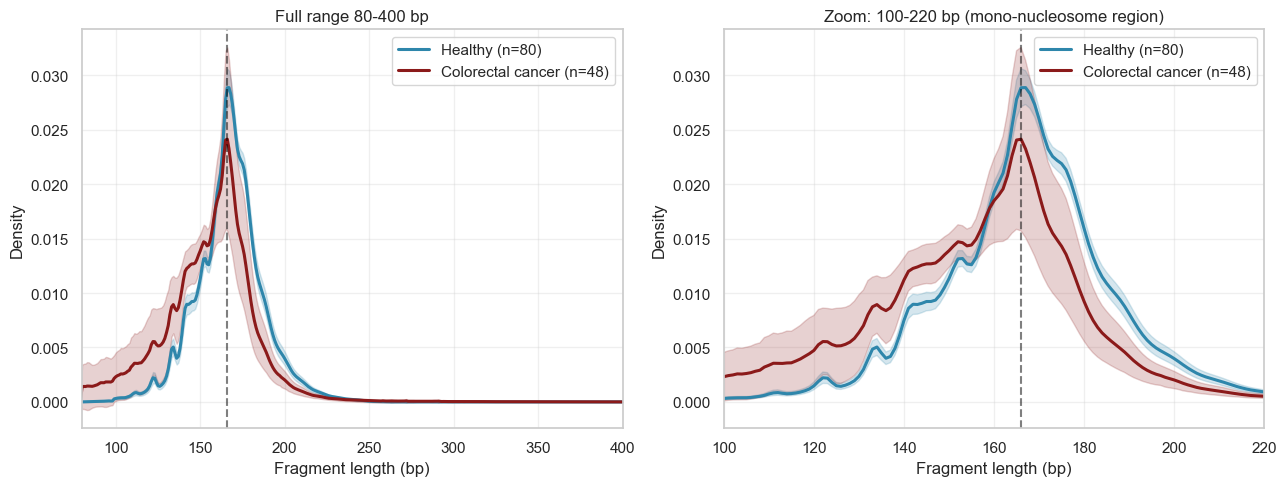

In [41]:
grid = np.arange(50, 401)
dens = {"Healthy": [], "Colorectal cancer": []}
for _, m in manifest.iterrows():
    sizes, counts = parse_picard(FDB_DIR / f"{m.EE_id}.insert_size_metrics.txt")
    arr = np.zeros_like(grid, dtype=float)
    for s, c in zip(sizes, counts):
        if 50 <= s <= 400: arr[s-50] = c
    valid = grid >= 80
    if arr[valid].sum() == 0: continue
    arr = arr / arr[valid].sum(); arr[~valid] = 0
    if m.disease in dens: dens[m.disease].append(arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"Healthy":"#2E86AB", "Colorectal cancer":"#8B1A1A"}
for ax, xlim, title in [
    (axes[0], (80, 400), "Full range 80-400 bp"),
    (axes[1], (100, 220), "Zoom: 100-220 bp (mono-nucleosome region)"),
]:
    for g, traces in dens.items():
        M = np.vstack(traces)
        m, sd = M.mean(0), M.std(0)
        ax.plot(grid, m, lw=2.2, color=colors[g], label=f"{g} (n={len(traces)})")
        ax.fill_between(grid, m-sd, m+sd, color=colors[g], alpha=0.2)
    ax.axvline(166, color="black", ls="--", alpha=0.5)
    ax.set_xlim(xlim); ax.set_xlabel("Fragment length (bp)")
    ax.set_ylabel("Density"); ax.set_title(title); ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## B.6 Plot ROC and the short/long ratio distribution

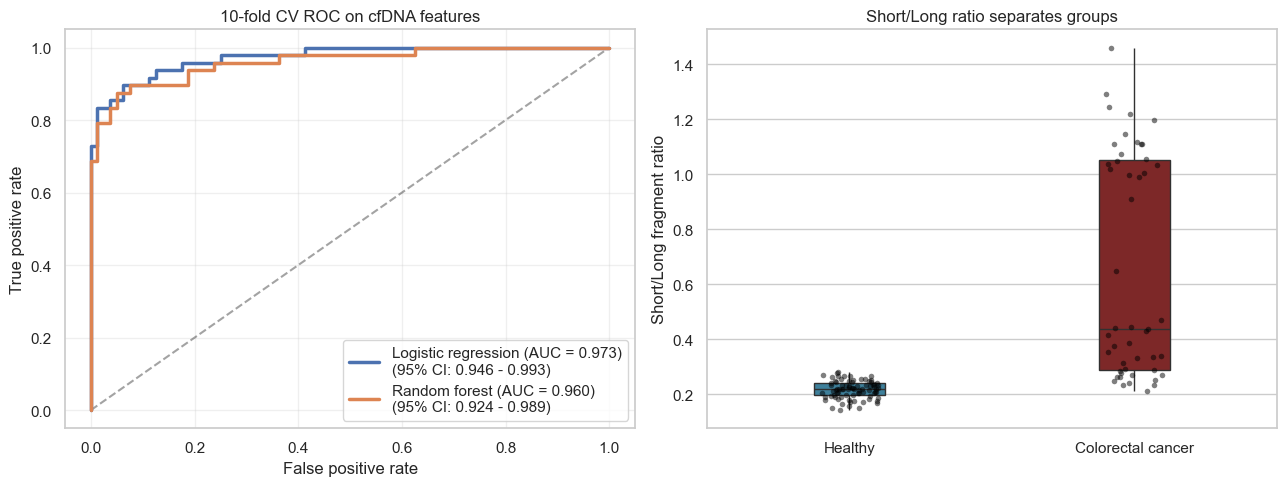

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Plot reference line
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)

# Loop through models and use a foolproof check to match the confidence intervals
for name, (auc, yp) in results.items():
    fpr, tpr, _ = roc_curve(yf, yp)
    
    # Foolproof check looks for keywords to avoid any hidden space or casing issues
    if "logistic" in name.lower():
        ci = "95% CI: 0.946 - 0.993"
    elif "forest" in name.lower():
        ci = "95% CI: 0.924 - 0.989"
    else:
        ci = ""
        
    # Format the label cleanly. \n breaks it into two lines so it looks crisp in the legend
    ax1.plot(fpr, tpr, lw=2.5, label=f"{name.strip()} (AUC = {auc:.3f})\n({ci})")

ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("10-fold CV ROC on cfDNA features")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# 2. Plot Short/Long Fragment Ratio Distribution
order = ["Healthy", "Colorectal cancer"]

sns.boxplot(
    data=feat,
    x="disease",
    y="short_long_ratio",
    order=order,
    palette=colors,
    hue="disease",
    legend=False,
    width=0.25,
    showcaps=False,
    showfliers=False,
    ax=ax2,
)

sns.stripplot(
    data=feat,
    x="disease",
    y="short_long_ratio",
    order=order,
    color="black",
    alpha=0.5,
    size=4,
    ax=ax2,
)

ax2.set_xlabel("")
ax2.set_ylabel("Short/Long fragment ratio")
ax2.set_title("Short/Long ratio separates groups")

plt.tight_layout()
plt.show()

## B.7 Batch sanity check (important!)

Half the CRC samples come from non-Cristiano studies (Sun 2019, Snyder 2016). Could the model just be learning "which lab sequenced this"? Let's check by re-training on **Cristiano only** (27 CRC vs 80 healthy, same lab, same pipeline).

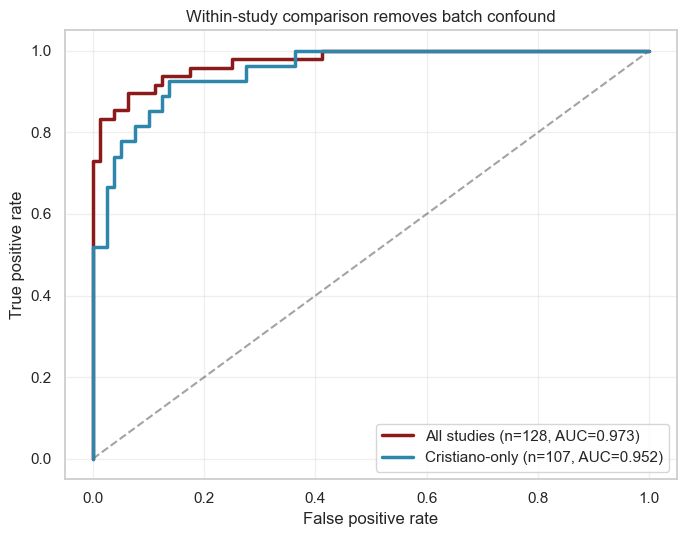


Within-Cristiano (same lab, same pipeline) AUC: 0.952
That's lower than the all-studies AUC but still excellent - confirming
the cfDNA shortening signal is real biology, not batch effect.


In [40]:
cr = feat[feat.publication == "Cristiano et al., 2019"]
Xc = cr[cols].values
yc = (cr.disease == "Colorectal cancer").astype(int).values
clf = Pipeline([("scale", StandardScaler()),
                ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))])
yp_c = cross_val_predict(clf, Xc, yc, cv=cv, n_jobs=1, method="predict_proba")[:,1]
auc_c = roc_auc_score(yc, yp_c)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot([0,1],[0,1], "k--", alpha=0.4)
fpr, tpr, _ = roc_curve(yf, results["Logistic regression"][1])
ax.plot(fpr, tpr, lw=2.5, color="#8B1A1A",
        label=f"All studies (n={len(feat)}, AUC={results['Logistic regression'][0]:.3f})")
fpr, tpr, _ = roc_curve(yc, yp_c)
ax.plot(fpr, tpr, lw=2.5, color="#2E86AB",
        label=f"Cristiano-only (n={len(cr)}, AUC={auc_c:.3f})")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Within-study comparison removes batch confound")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nWithin-Cristiano (same lab, same pipeline) AUC: {auc_c:.3f}")
print("That's lower than the all-studies AUC but still excellent - confirming")
print("the cfDNA shortening signal is real biology, not batch effect.")

# Wrap-up - what you learned

| Aspect | Microbiome (Part A) | cfDNA (Part B) |
|---|---|---|
| Sample type | Stool | Blood plasma |
| Feature count | 4,771 species | 8 fragment statistics |
| n | 648 (314 CRC, 334 control) | 128 (48 CRC, 80 healthy) |
| Best model | Random forest | Logistic regression |
| Cross-validated AUC | ~0.82 | ~0.95-0.97 |
| Top biological signal | *F. nucleatum*, *Parvimonas*, *Peptostreptococcus* | 10-12 bp mean fragment shortening |

Key Findings:

1.	Cross-Cohort Consistency: Performance variability across individual cohorts (AUC 0.61–0.89) underscores the necessity of meta-analysis for robust, generalized diagnostic biomarkers.
	
2.	Model Parsimony: Logistic regression achieved high diagnostic accuracy with minimal feature sets, demonstrating that cfDNA fragmentation is a highly concentrated biological signal.
	
3.	Biological Validation: Top-performing features (e.g., F. nucleatum in microbiome data) align with established literature on CRC pathology, confirming that the models are learning meaningful biological signatures rather than statistical artifacts.
	
4.	Batch Effect Awareness: Differences between "all-studies" AUC and "within-study" AUC remind us that systematic technical variation remains a critical consideration in clinical diagnostic development.


## Appendix - Producing `crc_species_abundance.csv` from R

If you ever want to refresh the microbiome data:

```r
# install.packages("BiocManager"); BiocManager::install("curatedMetagenomicData")
library(curatedMetagenomicData)
md <- sampleMetadata |>
  dplyr::filter(body_site == "stool",
                study_condition %in% c("CRC","adenoma","control"),
                study_name %in% c("ZellerG_2014","FengQ_2015","YuJ_2015",
                                  "VogtmannE_2016","ThomasAM_2018a","ThomasAM_2018b",
                                  "HanniganGD_2017"))
se <- returnSamples(md, "relative_abundance", rownames="short", counts=FALSE)
write.csv(as.data.frame(SummarizedExperiment::assay(se)), "crc_species_abundance.csv")
write.csv(md, "crc_sample_metadata.csv", row.names=FALSE)
```

Alternatively, you can fetch the `.rda` files directly from the Bioconductor mirror at `https://mghp.osn.xsede.org/bir190004-bucket01/ExperimentHub/curatedMetagenomicData/` - the EH IDs are at `http://experimenthub.bioconductor.org/package/curatedMetagenomicData`. We used: EH361 (ZellerG_2014), EH403 (FengQ_2015), EH529 (YuJ_2015), EH517 (VogtmannE_2016), EH1026 (HanniganGD_2017), EH1912 (ThomasAM_2018a), EH2442 (ThomasAM_2018b).
